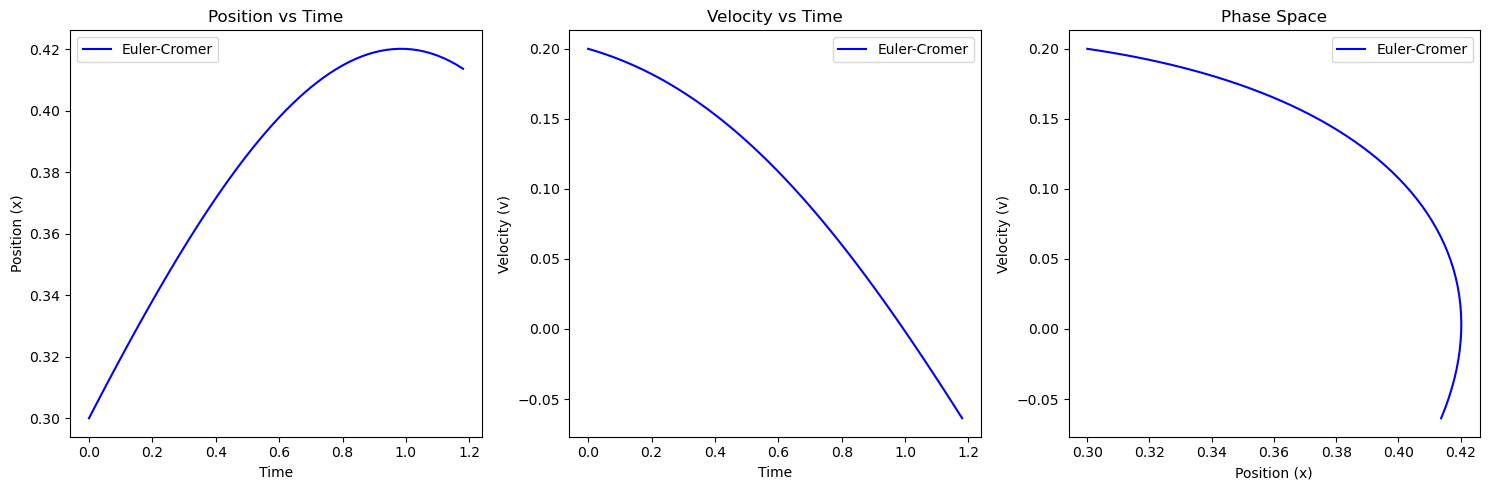

In [1]:
import numpy as np 
import matplotlib.pylab as plt

# Parameters for the Duffing equation
alpha = 1.0  # Linear stiffness
beta = 1.0   # Non-linear stiffness
delta = 0.2  # Damping
gamma = 0.3  # Amplitude of periodic forcing
omega = 1.0  # Angular frequency of periodic forcing
dt = 0.02    # Time step
xi, vi = 0.3, 0.2
n_steps=60

# Set Duffing eq for Neural Network comparison.


def duffing_acceleration(x, v, t):
    """Calculate acceleration from the Duffing equation"""
    return -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)

def euler_cromer_step(x, v, t):
    """
    Perform one Euler-Cromer step
    Returns: next position and velocity
    """
    # First update velocity (using current position)
    a = duffing_acceleration(x, v, t)
    v_next = v + a * dt
    
    # Then update position (using new velocity)
    x_next = x + v_next * dt
    
    return x_next, v_next

# Function to generate trajectory using Euler-Cromer
def generate_trajectory(xi, vi, n_steps):
    """Generate trajectory using Euler-Cromer method"""
    trajectory = np.zeros((n_steps, 2)) # Create empty array for x and v vals
    x, v = xi, vi 
    t = 0.0
    
    for i in range(n_steps):
        trajectory[i] = [x, v]
        x, v = euler_cromer_step(x, v, t) # Advance system and append vals in array.
        t += dt
    
    return trajectory


trajectory = generate_trajectory(xi, vi, n_steps)
t = np.arange(n_steps) * dt

# Plotting
plt.figure(figsize=(15, 5))

# Position plot
plt.subplot(131)
plt.plot(t, trajectory[:, 0], 'b-', label='Euler-Cromer')
plt.xlabel('Time')
plt.ylabel('Position (x)')
plt.legend()
plt.title('Position vs Time')

# Velocity plot
plt.subplot(132)
plt.plot(t, trajectory[:, 1], 'b-', label='Euler-Cromer')
plt.xlabel('Time')
plt.ylabel('Velocity (v)')
plt.legend()
plt.title('Velocity vs Time')

# Phase space plot
plt.subplot(133)
plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-', label='Euler-Cromer')
plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.legend()
plt.title('Phase Space')

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
from itertools import product
import pprint
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pylab as plt
import pygraphviz as pgv 
from tensorflow.keras import layers, models

from tensorflow.keras import layers
from tensorflow.keras.layers import Layer
from tensorflow.keras.utils import plot_model

from tensorflow.keras.callbacks import TerminateOnNaN, ModelCheckpoint
tf.keras.backend.set_floatx('float64') # Try float128 if possible??

print(tf.__version__)

class products(Layer):
    def __init__(self, units=32):
        super(products, self).__init__()
        self.units = units
        
    def build(self, input_shape):
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True,
            dtype=tf.float64
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=False,  # Properly tracked!
            dtype=tf.float64
        )
        
    def call(self, inputs):
        w = tf.complex(self.w, tf.constant(0.0, dtype=tf.float64))
        b = tf.complex(self.b, tf.constant(0.0, dtype=tf.float64))
        inp = tf.complex(inputs, tf.constant(1.0e-200, dtype=tf.float64))
        loginp = tf.math.log(inp)
        ret0 = tf.matmul(loginp, w)
        ret = tf.exp(ret0) * b
        return tf.math.real(ret)


class LogMSELoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        return tf.math.log(mse + tf.keras.backend.epsilon())

2025-04-25 18:06:00.737559: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 18:06:00.790400: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-25 18:06:00.790420: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-25 18:06:00.790446: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-25 18:06:00.798496: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 18:06:00.799343: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

2.14.1


In [5]:
import os

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
#random.seed(seed)
#np.random.seed(seed)
tf.random.set_seed(seed)

tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

os.environ['TF_DETERMINISTIC_OPS'] = '1'


In [6]:
from tensorflow.keras import backend as K # Custom log loss

# Define Log-MSE loss function
def log_mse_loss(y_true, y_pred):
    mse = K.mean(K.square(y_true - y_pred))  # Compute Mean Squared Error
    return K.log(mse + K.epsilon())  # Apply log transformation and avoid log(0

In [7]:
class WeightLogger(tf.keras.callbacks.Callback):
    def __init__(self, layer_name):
        super().__init__()
        self.layer_name = layer_name
        self.weight_history = []

    def on_epoch_end(self, epoch, logs=None):
        layer = self.model.get_layer(self.layer_name)
        weights = layer.get_weights()
        self.weight_history.append(weights)
        print(f"Epoch {epoch+1} | Weights: {weights[0].flatten()}")  


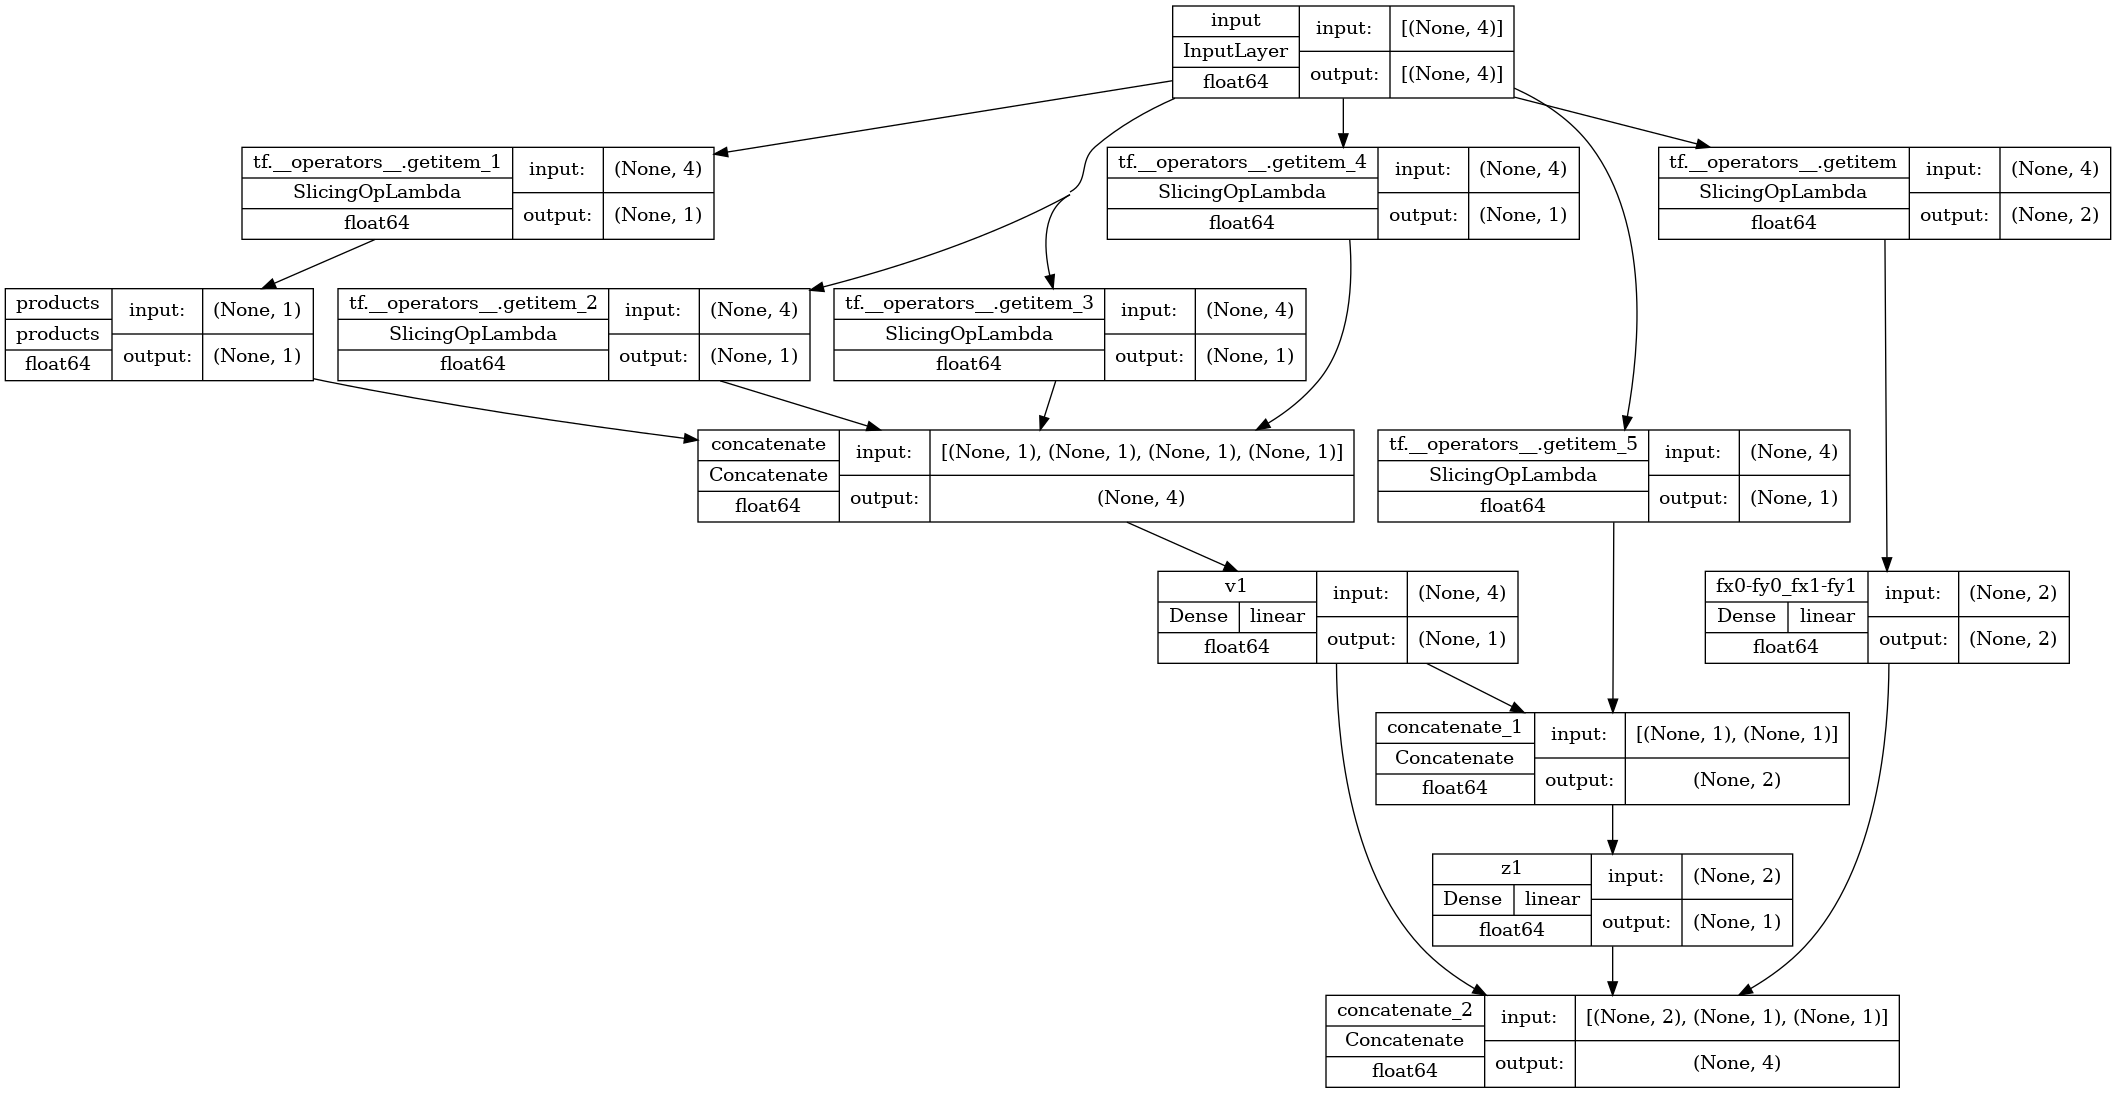

[<tf.Variable 'products/kernel:0' shape=(1, 1) dtype=float64, numpy=array([[3.]])>,
 <tf.Variable 'products/bias:0' shape=(1,) dtype=float64, numpy=array([1.])>,
 <tf.Variable 'v1/kernel:0' shape=(4, 1) dtype=float64, numpy=
array([[-0.02 ],
       [ 0.996],
       [-0.02 ],
       [ 0.006]])>,
 <tf.Variable 'fx0-fy0_fx1-fy1/kernel:0' shape=(2, 2) dtype=float64, numpy=
array([[ 0.99980001, -0.01999867],
       [ 0.01999867,  0.99980001]])>,
 <tf.Variable 'fx0-fy0_fx1-fy1/bias:0' shape=(2,) dtype=float64, numpy=array([0., 0.])>,
 <tf.Variable 'z1/kernel:0' shape=(2, 1) dtype=float64, numpy=
array([[1.  ],
       [0.02]])>]


In [8]:
eps = 0 # PINN


rot=np.array([[np.cos(omega*dt),np.sin(omega*dt)],[-np.sin(omega*dt),np.cos(omega*dt)]]) # Rotates a 2D vector by omega*dt.
rzzp=layers.Input(shape=(4,),name='input') # fx0,fy0,z0,v0 = *rot0,z0,v0

rot1=layers.Dense(units=2,activation='linear',name='fx0-fy0_fx1-fy1')(rzzp[:,:2]) # fx0,fy0->fx1,fy1.
rot1.node.layer.set_weights([np.array(rot).T, np.array([0.0,0.0])])# Apply rotation to previous pairing of fx0 and fy0. Bias is zero

z2=products(units=1)(rzzp[:,2:3]) # z->z^3
z2.node.layer.set_weights([np.array([[3.0+eps]]).T, np.array([1.0])]) # Construct non-linear term.

zz=layers.Concatenate()([rzzp[:,2:3],rzzp[:,3:],z2,rzzp[:,:1]]) 
v1=layers.Dense(units=1,activation='linear',name='v1',use_bias=False)(zz) # z,v,z^3,fx0 ->v1
v1.node.layer.set_weights([ np.array([[-alpha*dt,1-delta*dt,-beta*dt,gamma*dt]]).T])#, np.array([0.0])]) # Update for velocity based on Duffing eq- v1 = v0 + a*dt

zv1=layers.Concatenate()([rzzp[:,2:3],v1]) 
z1=layers.Dense(units=1,activation='linear',name='z1', use_bias=False)(zv1) # z0, v1 -> z1
z1.node.layer.set_weights([np.array([[1+eps,dt]]).T])#, np.array([0.0])])

outs=layers.Concatenate()([rot1,z1,v1]) # New force, pos, velocity...

model = models.Model(inputs=rzzp, outputs=outs)

display(plot_model(model, show_layer_names=True, show_shapes=True, show_dtype=True,show_layer_activations=True))

pprint.pprint(model.weights)


In [9]:
eps = 1e-7

model.compile(
    optimizer="SGD",
    loss= "LogMSELoss", # Try different loss and optimizer. logrms, Look into function of other optimizers.
)

model.get_layer('fx0-fy0_fx1-fy1').set_weights([np.array(rot).T+eps, np.array([0.0,0.0])+eps])
model.get_layer('products').set_weights([np.array([[3.0]]).T+eps, np.array([1.0])+eps])
model.get_layer('v1').set_weights([ np.array([[-alpha*dt+eps,1-delta*dt+eps,-beta*dt+eps,gamma*dt+eps]]).T])
model.get_layer('z1').set_weights([np.array([[1+eps,dt+eps]]).T])

pprint.pprint(model.weights)

[<tf.Variable 'products/kernel:0' shape=(1, 1) dtype=float64, numpy=array([[3.0000001]])>,
 <tf.Variable 'products/bias:0' shape=(1,) dtype=float64, numpy=array([1.0000001])>,
 <tf.Variable 'v1/kernel:0' shape=(4, 1) dtype=float64, numpy=
array([[-0.0199999],
       [ 0.9960001],
       [-0.0199999],
       [ 0.0060001]])>,
 <tf.Variable 'fx0-fy0_fx1-fy1/kernel:0' shape=(2, 2) dtype=float64, numpy=
array([[ 0.99980011, -0.01999857],
       [ 0.01999877,  0.99980011]])>,
 <tf.Variable 'fx0-fy0_fx1-fy1/bias:0' shape=(2,) dtype=float64, numpy=array([1.e-07, 1.e-07])>,
 <tf.Variable 'z1/kernel:0' shape=(2, 1) dtype=float64, numpy=
array([[1.0000001],
       [0.0200001]])>]


In [ ]:
import pandas as pd # Dataset generator
import numpy as np

#model.compile(
#    optimizer="SGD",
#    loss= "LogMSELoss", # Try different loss and optimizer. logrms, Look into function of other optimizers.
#)

sampleNo = 6000

# Generate valid initial conditions
om = np.random.uniform(0.9, 1.1, size=sampleNo)
z0 = np.random.uniform(-2, 2, size=sampleNo)
v0 = np.random.uniform(-2, 2, size=sampleNo)
t = np.random.uniform(0, 2 * np.pi, size=sampleNo)


fx0 = np.cos(om * t)
fy0 = np.sin(om * t)

breakpt = int(sampleNo/2)

X_train1 = np.stack([fx0[:breakpt], fy0[:breakpt], z0[:breakpt], v0[:breakpt]], axis=1)
X_val = np.stack([fx0[breakpt:], fy0[breakpt:], z0[breakpt:], v0[breakpt:]], axis=1)

y_train = []
y_val = []


# Compute next state for each sample
for i in range(sampleNo):
    ti, omi, fx, fy, v, z = t[i], om[i], fx0[i], fy0[i], v0[i], z0[i]
    
    fx1 = np.cos(omi * dt) * fx + np.sin(omi * dt) * fy
    fy1 = -np.sin(omi * dt) * fx + np.cos(omi * dt) * fy
    v1 = v + dt * (-alpha * z - delta * v - beta * z**3 + gamma * np.cos(omi * ti))
    z1 = z + v * dt  
    
    if i<breakpt:
        y_train.append([fx1, fy1, z1, v1])
    if i>=breakpt:    
        y_val.append([fx1, fy1, z1, v1])


y_train = np.array(y_train)
y_val = np.array(y_val)

X_train1 = tf.convert_to_tensor(X_train1, dtype=tf.float64)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float64)

#from tensorflow.keras.callbacks import TensorBoard

#tensorboard_callback = TensorBoard(log_dir='./logs', histogram_freq=1)

In [ ]:
from tensorflow.keras import Sequential # The code that begins here concerns the generic model.
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(256,activation="tanh"))
model.add(Dense(256,activation="tanh"))
model.add(Dense(256,activation="tanh"))
model.add(Dense(256,activation="tanh"))
model.add(Dense(256,activation="tanh"))
model.add(Dense(4,activation="linear"))

In [ ]:

model.compile(optimizer='adam'
              , loss = 'mse')

In [ ]:
weight_logger = WeightLogger('z1') # This training function was used for the PINN and the generic NN.

weight_logger2 = WeightLogger('fx0-fy0_fx1-fy1')

weight_logger3 = WeightLogger('v1')

weight_logger4 = WeightLogger('products_2')

logger = LossAndWeightLogger('log_with_weights.csv', layer_names=['v1', 'z1', 'products', 'fx0-fy0_fx1-fy1'])



def twosteptrain(model, X_train, y_train, batch_size=32, validation_data = (X_val, y_val)):

    optimizer1 = keras.optimizers.SGD(learning_rate = 0.00001,momentum=0.0)
    optimizer2 = keras.optimizers.SGD(learning_rate = 0.00000001, momentum=0.0)
    optimizer3 = keras.optimizers.SGD(learning_rate = 0.00000001, momentum=0.9)
    optimizer4 = keras.optimizers.Adam(learning_rate = 0.00000001, amsgrad = True)
    optimizer5 = keras.optimizers.SGD(learning_rate = 10E-10, momentum=0.0)
    optimizer6 = keras.optimizers.SGD(learning_rate = 0.000001, momentum=0.0)
    optimizer7 = keras.optimizers.SGD(learning_rate = 0.0000001, momentum=0.0)
    optimizer8 = keras.optimizers.SGD(learning_rate = 0.0001,momentum=0.0)
    # Step 1: MAE

   # model.compile(optimizer = optimizer2, loss = log_mse_loss)
    #model.fit(X_train, y_train, epochs = 2, batch_size=batch_size, validation_data = (X_val,y_val), use_multiprocessing = True, callbacks= [weight_logger3])


    
    model.compile(optimizer = optimizer1, loss = 'mse')
    history1 = model.fit(X_train, y_train, epochs = 1000, batch_size=batch_size, validation_data = (X_val,y_val), use_multiprocessing = True, callbacks= [weight_logger3, logger])

    # Step 2: logMAE

    #model.compile(optimizer = optimizer6, loss = "mse")
    #history2 = model.fit(X_train, y_train, epochs = 30, batch_size=16, validation_data = (X_val,y_val), use_multiprocessing = True, callbacks= [weight_logger3])
    
    #model.compile(optimizer = optimizer5, loss = "mse")
    #history3 = model.fit(X_train, y_train, epochs = 30, batch_size=16, validation_data = (X_val,y_val), use_multiprocessing = True, callbacks= [weight_logger])
     # Plot the training and validation loss
    history_df = pd.DataFrame(history1.history)
    
    plt.figure(figsize=(10, 6))
    plt.plot(history_df['loss'], label='Training Loss')
    if 'val_loss' in history_df.columns:
        plt.plot(history_df['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    

In [ ]:
%%time

xs1 = [[np.cos(omega*0), np.sin(omega*0),xi,vi]]
trj1=[]
for i in range(n_steps):
    trj1.append(xs1[0])
    
    xs1= model.predict(xs1,verbose=0) # Predict trajectory with NN.
    
nn_trajectory1=np.array(trj1)

In [ ]:
xs1 = [[np.cos(omega*0), np.sin(omega*0),xi,vi]]
pred1=model.predict(xs1)
#pred2=model2.predict(xs1)


plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-', label='Euler-Cromer')
plt.plot(nn_trajectory1[:, 2], nn_trajectory1[:,3], 'r--', label='Neural Network 1 step')
#plt.plot(nn_trajectory2[:, 2], nn_trajectory2[:,3], 'g--', label='Neural Network ns step')
#plt.plot(pred1[0][2::4], pred1[0,3::4], 'r-')
#plt.plot(pred2[0][2::4], pred2[0,3::4], 'g-')

plt.xlabel('Position (x)')
plt.ylabel('Velocity (v)')
plt.legend()
plt.title('Phase Space');


NameError: name 'generic_model' is not defined